# **Project Report - 6**

# **Bachelor of Computer Applications (BCA)**

# **Semester – V**

#### **Sub:** Deep Learning

#### **Topic:** Simple Neural Network Forward Propagation

#### **Implementation, Forward Propagation, Activation Function and Iris Flower Classification Using Python**

#### **Submitted By**

#### **Name:** Pragathi BR

#### **Reg no:** 2411021240037

#### **Date of Submission:** 27/09/2026

#### **Faculty Name:** Nagasri. P

# **Simple Neural Network Forward Propagation**

## **Using the Iris Classification Dataset**

### **Objective**

The objective of this project is to create a basic neural network
using the Iris classification dataset and understand how a neural
network processes input data and generates predictions using
forward propagation.

In this project, the Iris dataset is loaded and prepared, a simple
neural network is created using Python and NumPy, forward propagation
is performed, activation functions are applied, and the predicted
Iris flower classes are displayed.

# **1. Introduction**

A neural network is a machine learning model inspired by the
structure of the human brain. It consists of interconnected
neurons arranged in different layers.

A basic neural network generally contains:

- Input Layer
- Hidden Layer
- Output Layer

In this project, a simple neural network is implemented for
Iris flower classification.

The Iris dataset contains measurements of flowers belonging
to three different species:

- Iris Setosa
- Iris Versicolor
- Iris Virginica

The network receives four measurements as input and produces
three output values representing the three possible flower
classes.

The main focus of this project is **forward propagation**, where
the input data moves through the neural network from the input
layer to the output layer to generate a prediction.

# **2. Objectives**

The main objectives of this project are:

1. To load the Iris classification dataset.
2. To understand the input features and target classes.
3. To prepare the dataset for neural network processing.
4. To create a simple neural network architecture.
5. To initialize weights and biases.
6. To understand forward propagation.
7. To apply the ReLU activation function.
8. To apply the Softmax activation function.
9. To generate prediction probabilities.
10. To display the predicted Iris flower species.
11. To understand how a neural network converts input features
    into classification outputs.

# **3. Iris Dataset**

The Iris dataset is a commonly used dataset for classification
problems and machine learning experiments.

It contains **150 flower samples** belonging to three species.

Each sample contains four numerical features:

| Feature | Description |
|---|---|
| Sepal Length | Length of the sepal |
| Sepal Width | Width of the sepal |
| Petal Length | Length of the petal |
| Petal Width | Width of the petal |

The three target classes are:

| Class Number | Species |
|---|---|
| 0 | Iris Setosa |
| 1 | Iris Versicolor |
| 2 | Iris Virginica |

Therefore, the neural network has **4 input features** and
**3 output classes**.

In [ ]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# **4. Required Libraries**

The following Python libraries are used:

### **NumPy**
Used for numerical calculations, arrays and matrix operations.

### **Pandas**
Used to create and display the dataset in tabular form.

### **Matplotlib**
Used for visualizing the output probabilities.

### **Scikit-learn**
Used to load the Iris dataset and perform data splitting
and feature standardization.

# **Task 1: Load and Prepare the Iris Dataset**

The first task is to load the Iris dataset and prepare it for
classification.

The dataset contains 150 samples, 4 input features and 3 target
classes.

In [ ]:
# Load the Iris dataset

iris = load_iris()

# Store input features
X = iris.data

# Store target values
y = iris.target

# Store feature names
feature_names = iris.feature_names

# Store target names
target_names = iris.target_names

print("Dataset loaded successfully!")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of classes:", len(target_names))

Dataset loaded successfully!
Number of samples: 150
Number of features: 4
Number of classes: 3


In [ ]:
# Convert the Iris dataset into a Pandas DataFrame

df = pd.DataFrame(X, columns=feature_names)

# Add target column
df["Target"] = y

# Add species names
df["Species"] = df["Target"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

# Display first 10 rows
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target,Species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
5,5.4,3.9,1.7,0.4,0,Setosa
6,4.6,3.4,1.4,0.3,0,Setosa
7,5.0,3.4,1.5,0.2,0,Setosa
8,4.4,2.9,1.4,0.2,0,Setosa
9,4.9,3.1,1.5,0.1,0,Setosa


# **5. Dataset Features and Classes**

The dataset contains four input features:

1. **Sepal Length**
2. **Sepal Width**
3. **Petal Length**
4. **Petal Width**

The target variable contains three classes:

- **0 → Iris Setosa**
- **1 → Iris Versicolor**
- **2 → Iris Virginica**

These four numerical features are given to the neural network as
input, and the network generates probabilities for the three
possible classes.

In [ ]:
# Display dataset information

print("Dataset Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nInput Features:")
for feature in feature_names:
    print("-", feature)

print("\nTarget Classes:")
for i, target in enumerate(target_names):
    print(i, "->", target)

Dataset Shape: (150, 4)
Target Shape: (150,)

Input Features:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)

Target Classes:
0 -> setosa
1 -> versicolor
2 -> virginica


# **6. Checking the Dataset**

Before using the dataset, it is useful to check whether there are
missing values.

The Iris dataset provided by Scikit-learn is already clean and
does not contain missing values.

In [ ]:
# Check for missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Target               0
Species              0
dtype: int64


# **7. Splitting the Dataset**

The dataset is divided into training and testing data.

For this project:

- **80%** of the data is used as training data.
- **20%** of the data is used as testing data.

Although the main purpose of this assignment is forward propagation,
the split helps demonstrate how input data can be prepared for a
classification neural network.

In [ ]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


# **8. Feature Scaling**

The four Iris features have different numerical ranges.

To make the input values easier for the neural network to process,
the features are standardized.

Standardization transforms the values so that the features have
approximately:

- Mean = 0
- Standard deviation = 1

The StandardScaler from Scikit-learn is used for this purpose.

In [ ]:
# Create StandardScaler

scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

print("First five scaled training samples:")
print(X_train_scaled[:5])

First five scaled training samples:
[[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]
 [ 1.14439475 -0.5559895   0.58484978  0.25675496]
 [-1.12449223  0.11567567 -1.28894078 -1.45494479]
 [-0.40800161 -1.22765467  0.13059752  0.12508575]]


# **Task 2: Build a Simple Neural Network**

A simple neural network is created with three layers:

### **Input Layer**
Contains 4 neurons because the dataset contains four input
features.

### **Hidden Layer**
Contains 5 neurons.

### **Output Layer**
Contains 3 neurons because there are three Iris flower classes.

Therefore, the architecture is:

**4 Input Neurons → 5 Hidden Neurons → 3 Output Neurons**

The structure can be represented as:

```text
Input Layer
     |
     | 4 Features
     ↓
Hidden Layer
     |
     | 5 Neurons
     | ReLU Activation
     ↓
Output Layer
     |
     | 3 Neurons
     | Softmax Activation
     ↓
Predicted Class

# **9. Weights and Biases**

Weights and biases are important components of a neural network.

Weights determine the strength of connections between neurons,
while biases help shift the activation values.

For our neural network:

- Input neurons = 4
- Hidden neurons = 5
- Output neurons = 3

Therefore:

**W1:** 4 × 5

**b1:** 1 × 5

**W2:** 5 × 3

**b2:** 1 × 3

The weights are initialized with small random values and the
biases are initialized with zeros.

In [ ]:
# Set random seed for reproducible results

np.random.seed(42)

# Define number of neurons
input_neurons = 4
hidden_neurons = 5
output_neurons = 3

# Initialize weights and biases

W1 = np.random.randn(input_neurons, hidden_neurons) * 0.1
b1 = np.zeros((1, hidden_neurons))

W2 = np.random.randn(hidden_neurons, output_neurons) * 0.1
b2 = np.zeros((1, output_neurons))

# Display shapes

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (4, 5)
b1 shape: (1, 5)
W2 shape: (5, 3)
b2 shape: (1, 3)


# **10. Forward Propagation**

Forward propagation is the process of passing input data through
the neural network from the input layer to the output layer.

The process is performed in the following steps:

### **Step 1: Hidden Layer Weighted Sum**

The input is multiplied by the first weight matrix and the bias
is added.

**Z₁ = XW₁ + b₁**

### **Step 2: Hidden Layer Activation**

The ReLU activation function is applied.

**A₁ = ReLU(Z₁)**

### **Step 3: Output Layer Weighted Sum**

The hidden layer output is passed to the output layer.

**Z₂ = A₁W₂ + b₂**

### **Step 4: Output Activation**

The Softmax activation function converts the output values into
probabilities.

**A₂ = Softmax(Z₂)**

### **Step 5: Prediction**

The class with the highest probability is selected.

**Prediction = argmax(A₂)**

# **11. Activation Functions**

Activation functions determine how a neuron responds to its input.

In this project, two activation functions are used:

## **ReLU**

ReLU stands for Rectified Linear Unit.

The mathematical expression is:

**ReLU(x) = max(0, x)**

If the input is negative, ReLU returns 0.
If the input is positive, ReLU returns the same value.

ReLU is used in the hidden layer.

## **Softmax**

Softmax converts the output values into probabilities.

The probabilities represent the likelihood of each Iris class.

The three output probabilities correspond to:

- Setosa
- Versicolor
- Virginica

Softmax is used in the output layer.

In [ ]:
# Define ReLU activation function

def relu(x):
    return np.maximum(0, x)

In [ ]:
# Define Softmax activation function

def softmax(x):

    # Numerical stability
    exp_values = np.exp(
        x - np.max(x, axis=1, keepdims=True)
    )

    return exp_values / np.sum(
        exp_values,
        axis=1,
        keepdims=True
    )

# **12. Implementing Forward Propagation**

The following function performs the complete forward propagation
process.

The input data first passes through the hidden layer, where the
weighted sum and bias are calculated.

The ReLU activation function is then applied.

The activated hidden-layer output is passed to the output layer.

Finally, Softmax is applied to generate the class probabilities.

In [ ]:
# Define forward propagation function

def forward_propagation(X):

    # Hidden layer weighted sum
    Z1 = np.dot(X, W1) + b1

    # Apply ReLU
    A1 = relu(Z1)

    # Output layer weighted sum
    Z2 = np.dot(A1, W2) + b2

    # Apply Softmax
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

# **13. Performing Forward Propagation**

The test dataset is now passed through the neural network.

The network calculates:

1. Hidden layer weighted values.
2. ReLU activated values.
3. Output layer weighted values.
4. Softmax probabilities.

In [ ]:
# Perform forward propagation on test data

Z1, A1, Z2, A2 = forward_propagation(X_test_scaled)

print("Hidden layer output shape:", A1.shape)
print("Output layer output shape:", A2.shape)

Hidden layer output shape: (30, 5)
Output layer output shape: (30, 3)


# **14. Hidden Layer Output**

The hidden layer receives the four input features and calculates
five neuron values.

The ReLU activation function is then applied.

Negative values are converted to zero, while positive values
remain unchanged.

The resulting values are passed to the output layer.

In [ ]:
# Display hidden layer values for the first sample

print("Hidden Layer Weighted Values:")
print(Z1[0])

print("\nHidden Layer Activated Values after ReLU:")
print(A1[0])

Hidden Layer Weighted Values:
[ 0.0564216   0.20605829 -0.19532747  0.1313753   0.46324699]

Hidden Layer Activated Values after ReLU:
[0.0564216  0.20605829 0.         0.1313753  0.46324699]


# **15. Output Layer**

The output layer contains three neurons.

Each output neuron corresponds to one Iris flower species:

- Output Neuron 1 → Setosa
- Output Neuron 2 → Versicolor
- Output Neuron 3 → Virginica

The Softmax activation function converts the output values into
probabilities.

The sum of the three probabilities for each sample is equal to 1.

In [ ]:
# Display output probabilities for the first 5 samples

print("Output Probabilities:\n")

for i in range(5):

    print("Sample", i + 1)
    print("Setosa:", round(A2[i][0], 4))
    print("Versicolor:", round(A2[i][1], 4))
    print("Virginica:", round(A2[i][2], 4))
    print("Probability Sum:", round(np.sum(A2[i]), 4))
    print()

Output Probabilities:

Sample 1
Setosa: 0.3277
Versicolor: 0.3136
Virginica: 0.3587
Probability Sum: 1.0

Sample 2
Setosa: 0.3321
Versicolor: 0.3348
Virginica: 0.3331
Probability Sum: 1.0

Sample 3
Setosa: 0.3336
Versicolor: 0.3322
Virginica: 0.3342
Probability Sum: 1.0

Sample 4
Setosa: 0.3339
Versicolor: 0.3324
Virginica: 0.3337
Probability Sum: 1.0

Sample 5
Setosa: 0.3259
Versicolor: 0.3138
Virginica: 0.3603
Probability Sum: 1.0



# **16. Generating Predictions**

The Softmax function produces three probability values for each
test sample.

The `argmax()` function is used to identify the position of the
highest probability.

For example, if the output is:

```text
Setosa       = 0.20
Versicolor   = 0.65
Virginica    = 0.15

In [ ]:
#  CODE: GENERATE PREDICTIONS

# Generate predicted class numbers

y_pred = np.argmax(A2, axis=1)

print("Predicted Class Numbers:")
print(y_pred)

Predicted Class Numbers:
[2 1 2 0 2 1 2 2 1 0 1 1 1 1 2 2 2 0 1 1 2 1 2 0 1 1 2 2 1 2]


In [ ]:
# Convert numerical predictions into species names

predicted_species = [
    target_names[i]
    for i in y_pred
]

print("Predicted Iris Species:\n")

for i in range(10):
    print(
        f"Sample {i + 1}: "
        f"{predicted_species[i]}"
    )

Predicted Iris Species:

Sample 1: virginica
Sample 2: versicolor
Sample 3: virginica
Sample 4: setosa
Sample 5: virginica
Sample 6: versicolor
Sample 7: virginica
Sample 8: virginica
Sample 9: versicolor
Sample 10: setosa


# **17. Actual vs Predicted Classes**

The actual class of each test sample can be compared with the
class generated by the neural network.

Since this project focuses on **forward propagation**, the
weights are randomly initialized and are not trained using a
backpropagation algorithm.

Therefore, the predictions are mainly used to demonstrate how
the forward propagation process generates an output.

In [ ]:
# Create Actual vs Predicted comparison

comparison = pd.DataFrame({
    "Actual Class": [
        target_names[i]
        for i in y_test
    ],

    "Predicted Class": predicted_species
})

# Display first 15 predictions

comparison.head(15)

,Actual Class,Predicted Class
0,setosa,virginica
1,virginica,versicolor
2,versicolor,virginica
3,versicolor,setosa
4,setosa,virginica
5,versicolor,versicolor
6,setosa,virginica
7,setosa,virginica
8,virginica,versicolor
9,versicolor,setosa


# **18. Predicted Probability Table**

The probability table displays the probability assigned to each
Iris flower species.

For every sample, there are three probability values:

- Setosa Probability
- Versicolor Probability
- Virginica Probability

The largest probability determines the final predicted class.

In [ ]:
# Create probability DataFrame

probability_df = pd.DataFrame(
    A2,
    columns=[
        "Setosa Probability",
        "Versicolor Probability",
        "Virginica Probability"
    ]
)

# Add predicted class
probability_df["Predicted Class"] = predicted_species

# Display first 10 rows
probability_df.head(10)

,Setosa Probability,Versicolor Probability,Virginica Probability,Predicted Class
0,0.327655,0.313599,0.358746,virginica
1,0.332138,0.334776,0.333086,versicolor
2,0.333601,0.332178,0.334221,virginica
3,0.333927,0.332382,0.333691,setosa
4,0.325872,0.313804,0.360324,virginica
5,0.330736,0.336348,0.332916,versicolor
6,0.321345,0.310893,0.367762,virginica
7,0.323352,0.310816,0.365832,virginica
8,0.331139,0.335984,0.332877,versicolor
9,0.333333,0.333333,0.333333,setosa


# **19. Visualization of Predicted Output**

Visualization helps us understand the probabilities produced
by the output layer.

The following graph displays the three predicted probabilities
for the first 10 test samples.

The three lines represent:

- Setosa
- Versicolor
- Virginica

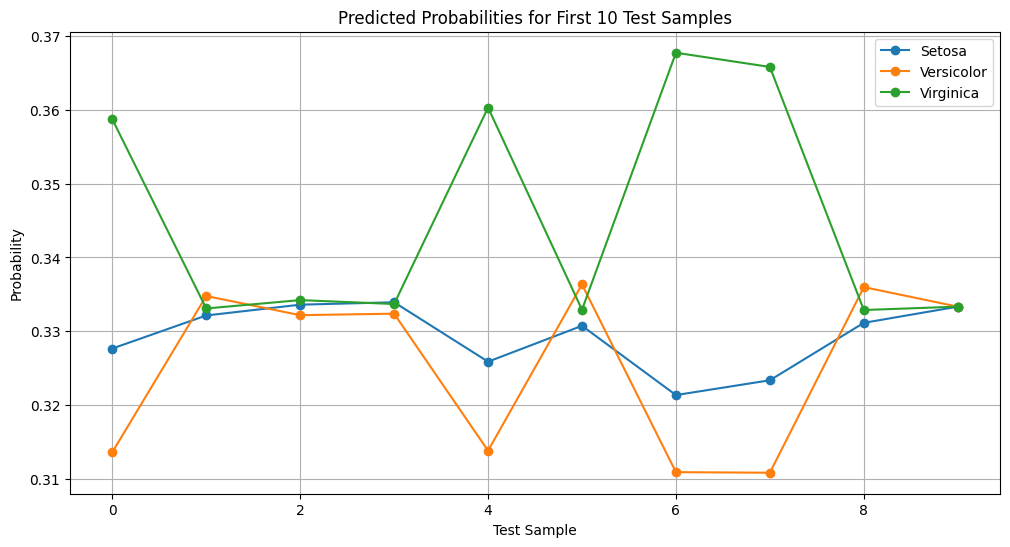

In [ ]:
# Visualize probabilities for first 10 test samples

first_10 = A2[:10]

plt.figure(figsize=(12, 6))

plt.plot(
    first_10[:, 0],
    marker='o',
    label='Setosa'
)

plt.plot(
    first_10[:, 1],
    marker='o',
    label='Versicolor'
)

plt.plot(
    first_10[:, 2],
    marker='o',
    label='Virginica'
)

plt.xlabel("Test Sample")
plt.ylabel("Probability")

plt.title(
    "Predicted Probabilities for First 10 Test Samples"
)

plt.legend()
plt.grid(True)

plt.show()

# **20. Forward Propagation Process**

The complete forward propagation process can be summarized as:

```text
                Input Data
                    |
                    ↓
       4 Iris Input Features
                    |
                    ↓
          Weighted Sum + Bias
                    |
                    ↓
             ReLU Activation
                    |
                    ↓
          Hidden Layer Output
                    |
                    ↓
          Weighted Sum + Bias
                    |
                    ↓
           Softmax Activation
                    |
                    ↓
         Class Probabilities
                    |
                    ↓
             Argmax Function
                    |
                    ↓
          Predicted Iris Class

The four input features are processed by the hidden layer.
The ReLU activation transforms the hidden-layer values.
The output layer then produces three values, and Softmax converts
them into probabilities.

# **21. Mathematical Representation**

The forward propagation process can be represented mathematically.

### **Hidden Layer**

The weighted sum is:

**Z₁ = XW₁ + b₁**

where:

- X = Input data
- W₁ = First layer weights
- b₁ = First layer bias

### **ReLU Activation**

**A₁ = ReLU(Z₁)**

The ReLU function is:

**ReLU(x) = max(0, x)**

### **Output Layer**

The output weighted sum is:

**Z₂ = A₁W₂ + b₂**

where:

- A₁ = Hidden layer activation
- W₂ = Second layer weights
- b₂ = Second layer bias

### **Softmax Activation**

**A₂ = Softmax(Z₂)**

The Softmax output represents the probability of each class.

### **Final Prediction**

**Prediction = argmax(A₂)**

The class with the largest probability becomes the predicted
Iris flower species.

# **22. Sample Prediction Interpretation**

Suppose the neural network produces the following output:

| Class | Probability |
|---|---:|
| Setosa | 0.20 |
| Versicolor | 0.65 |
| Virginica | 0.15 |

The probabilities add up to 1.

The highest probability is:

**Versicolor = 0.65**

Therefore, the predicted flower species is:

### **Iris Versicolor**

This demonstrates how the output of a neural network can be
converted into a classification prediction.

# **23. Observation**

The neural network successfully performs the forward propagation
process on the Iris dataset.

The following observations can be made:

1. The Iris dataset contains four input features.
2. The neural network contains five hidden neurons.
3. ReLU is used as the hidden-layer activation function.
4. The output layer contains three neurons.
5. Softmax converts the output values into probabilities.
6. The three probabilities correspond to the three Iris species.
7. The class with the highest probability is selected as the
   predicted class.
8. Since the weights are randomly initialized and the network is
   not trained, the predictions are not expected to have high
   classification accuracy.
9. The main purpose of this project is to understand forward
   propagation and how neural networks generate predictions.

# **24. Result**

The Iris dataset was successfully loaded and prepared for
classification.

A simple neural network with the following architecture was
implemented:

**4 Input Neurons → 5 Hidden Neurons → 3 Output Neurons**

Forward propagation was successfully performed using Python
and NumPy.

The ReLU activation function was applied to the hidden layer,
and the Softmax activation function was applied to the output
layer.

The output layer generated probability values for the three
Iris flower species:

- Iris Setosa
- Iris Versicolor
- Iris Virginica

The class with the highest probability was selected as the
predicted output.

# **25. Expected Output / Result**

The expected output of this project includes:

1. Iris dataset successfully loaded.
2. Dataset information and features displayed.
3. Training and testing datasets created.
4. Input features standardized.
5. Neural network weights and biases initialized.
6. Hidden-layer values generated.
7. ReLU activation applied.
8. Output-layer values generated.
9. Softmax probabilities calculated.
10. Predicted Iris classes displayed.
11. Actual and predicted classes compared.
12. Probability visualization generated.

The project demonstrates how a neural network processes input
features and generates classification predictions through
forward propagation.

# **26. Conclusion**

In this project, a simple neural network was implemented using
Python and NumPy for Iris flower classification.

The Iris dataset was loaded and prepared by separating the input
features and target classes. The dataset was divided into training
and testing data, and the input features were standardized.

A neural network consisting of an input layer, a hidden layer,
and an output layer was created. The input layer contained four
neurons, the hidden layer contained five neurons, and the output
layer contained three neurons.

Forward propagation was then performed. The input values were
multiplied by weights and biases were added. The ReLU activation
function was applied in the hidden layer. The output layer then
used the Softmax activation function to generate probabilities
for the three Iris flower classes.

Finally, the class with the highest probability was selected as
the predicted Iris species.

This project helped in understanding the basic structure of a
neural network, the role of activation functions, and the complete
forward propagation process used to generate predictions.